# Ejercicio 1

Conociendo la ecuación general de una transformación lineal:

$$s = ar + c$$

con $r$: valor de entrada, $a$: factor de ganancia y $c$: offset, realice los siguientes ejercicios:

1. Implemente una LUT del mapeo entre la entrada y la salida
2. Pruebe la rutina con diferentes juegos de coeficientes $a$ y $c$, sobre diversas imágenes, y muestre en una misma ventana la imagen original, el mapeo aplicado y la imagen obtenida.
3. Implemente el negativo de la imagen de entrada.
4. Genere diversas LUT con estiramientos y compresiones lineales por tramos de la entrada, y pruebe los resultados sobre diversas imágenes.
5. *(Opcional)*: genere una imagen binaria de 256x256 que simule los ejes cartesianos de la transformación $r-s$, marcando la línea identidad. Capture dos puntos que marquen el final de los segmentos, y genere la LUT con una transformación que parta del origen, pase por los puntos marcados, y finalice en el punto (256, 256). Pruebe la rutina con diversas imágenes. **Recomendación**: utilizar matplotlib con subplots, y para manejos de eventos ver `event handling`.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import helpers

img_huang = cv2.imread("imagenes/huang1.jpg", cv2.IMREAD_GRAYSCALE)
img_hubble = cv2.imread("imagenes/hubble.tif", cv2.IMREAD_GRAYSCALE)

### LUTs lineales por tramos

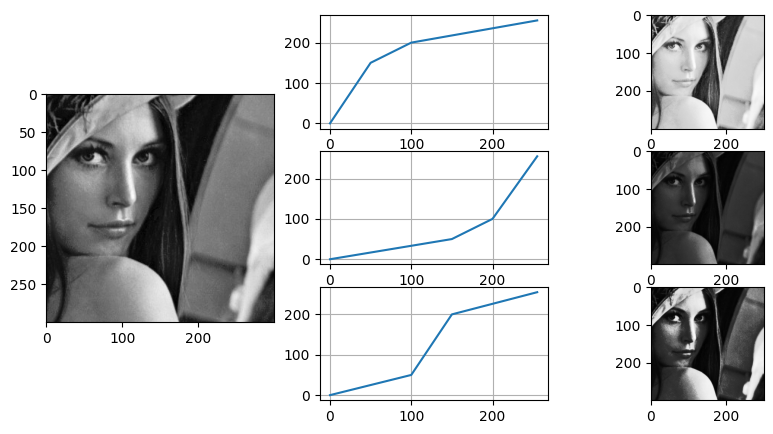

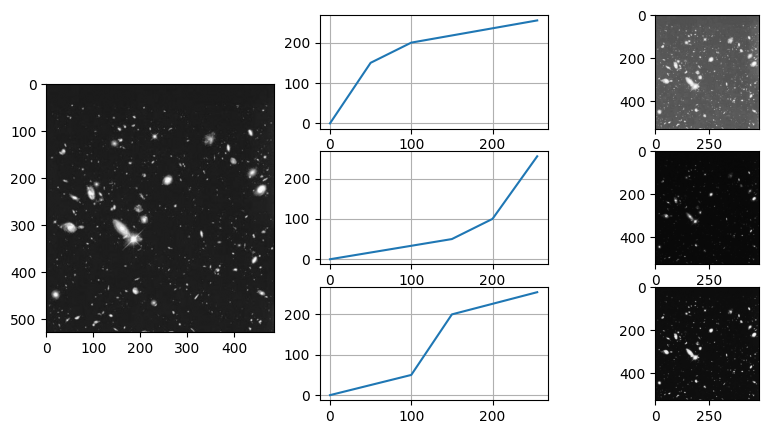

In [7]:
lut1 = helpers.breakpoints2LUT([50, 150], [100, 200])
lut2 = helpers.breakpoints2LUT([150, 50], [200, 100])
lut3 = helpers.breakpoints2LUT([100, 50], [150, 200])

# img 1
fig = plt.figure()
ax = [
    plt.subplot2grid((3,3), (0,0), rowspan=3),
    plt.subplot2grid((3,3), (0,1)),
    plt.subplot2grid((3,3), (0,2)),
    plt.subplot2grid((3,3), (1,1)),
    plt.subplot2grid((3,3), (1,2)),
    plt.subplot2grid((3,3), (2,1)),
    plt.subplot2grid((3,3), (2,2)),
]
fig.set_figwidth(10)
fig.set_figheight(5)

ax[0].imshow(img_huang, cmap='gray')
ax[1].grid()
ax[1].plot(lut1)
ax[2].imshow(cv2.LUT(img_huang, lut1), cmap='gray')
ax[3].grid()
ax[3].plot(lut2)
ax[4].imshow(cv2.LUT(img_huang, lut2), cmap='gray')
ax[5].grid()
ax[5].plot(lut3)
ax[6].imshow(cv2.LUT(img_huang, lut3), cmap='gray')

# img2
fig = plt.figure()
ax = [
    plt.subplot2grid((3,3), (0,0), rowspan=3),
    plt.subplot2grid((3,3), (0,1)),
    plt.subplot2grid((3,3), (0,2)),
    plt.subplot2grid((3,3), (1,1)),
    plt.subplot2grid((3,3), (1,2)),
    plt.subplot2grid((3,3), (2,1)),
    plt.subplot2grid((3,3), (2,2)),
]
fig.set_figwidth(10)
fig.set_figheight(5)

ax[0].imshow(img_hubble, cmap='gray')
ax[1].grid()
ax[1].plot(lut1)
ax[2].imshow(cv2.LUT(img_hubble, lut1), cmap='gray')
ax[3].grid()
ax[3].plot(lut2)
ax[4].imshow(cv2.LUT(img_hubble, lut2), cmap='gray')
ax[5].grid()
ax[5].plot(lut3)
ax[6].imshow(cv2.LUT(img_hubble, lut3), cmap='gray');

### Negativo

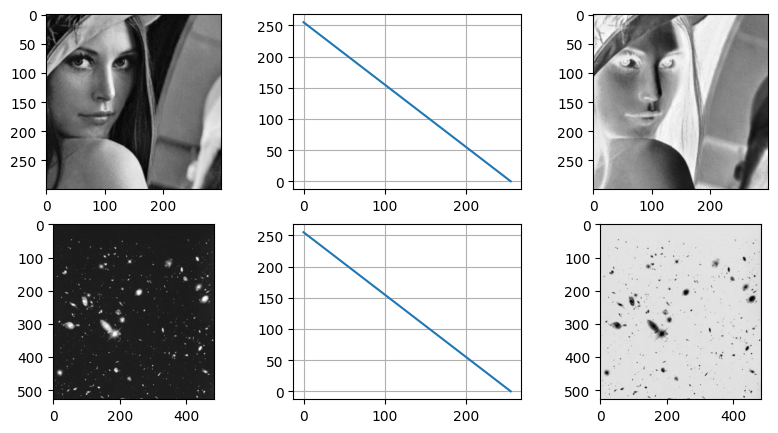

In [8]:
lut = helpers.LUTLineal(-1,255)

fig, ax = plt.subplots(2, 3)
fig.set_figwidth(10)
fig.set_figheight(5)

ax[0,0].imshow(img_huang, cmap='gray')
ax[0,1].grid()
ax[0,1].plot(lut)
ax[0,2].imshow(cv2.LUT(img_huang, lut), cmap='gray')
ax[1,0].imshow(img_hubble, cmap='gray')
ax[1,1].grid()
ax[1,1].plot(lut)
ax[1,2].imshow(cv2.LUT(img_hubble, lut), cmap='gray');

# Ejercicio 2

1. Implemente la transformación logarítmica $s = log(1+r)$ y la transformación de potencia $s = r^{\gamma}$ (c=1).
2. Realice el procesado sobre la imagen `rmn.jpg`, utilizando los dos procesos por separado.

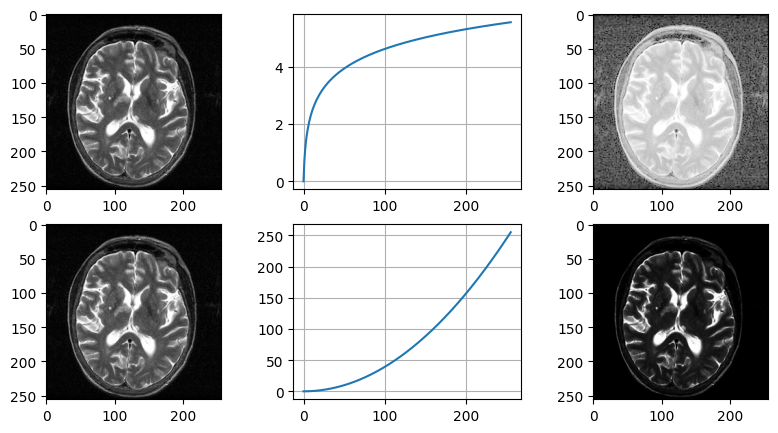

In [ ]:
img = cv2.imread("imagenes/rmn.jpg", cv2.IMREAD_GRAYSCALE)

lut_log = helpers.LUTLog()
lut_pot = helpers.LUTPotencia(2)

fig, ax = plt.subplots(2, 3)
fig.set_figwidth(10)
fig.set_figheight(5)

ax[0,0].imshow(img, cmap='gray')
ax[0,1].grid()
ax[0,1].plot(lut_log)
ax[0,2].imshow(cv2.LUT(img, lut_log), cmap='gray')
ax[1,0].imshow(img, cmap='gray')
ax[1,1].grid()
ax[1,1].plot(lut_pot)
ax[1,2].imshow(cv2.LUT(img, lut_pot), cmap='gray');

# Ejercicio 3

1. Implemente una función que realice las siguientes operaciones aritméticas sobre dos imágenes que sean pasadas como parámetros:
   1. Suma. Normalice el resultado por el número de imágenes.
   2. Diferencia. Aplique las dos funciones de reescalado usadas típicamente para evitar el desborde de rango (sumar 255, dividir por 2, o restar el mínimo y escalar a 255)
   3. Multiplicación. En esta operación la segunda imagen deberá ser una máscara binaria, muy utilizada para la extracción de la *región de interés* (ROI) de una imagen.
2. A partir de un video (`pedestrians.mp4`) de una cámara de seguridad, debe obtener solamente el fondo de la imagen. Incorpore un elemento TrackBar que le permita ir eligiendo el número de frames a promediar para observar los resultados instantáneamente.

In [10]:
from ipywidgets import interact, IntSlider

vid = cv2.VideoCapture("pedestrians.mp4")

max_frames = int(vid.get(cv2.CAP_PROP_FRAME_COUNT))
@interact(max_frames = IntSlider(min = 1, max = max_frames, step = 1, value = 60, description="frames"))

def update(max_frames):
    vid.set(cv2.CAP_PROP_POS_FRAMES, 0)
    img = helpers.promedioVideo(vid, max_frames)
    plt.imshow(img)
    plt.axis('off')
    plt.show();

interactive(children=(IntSlider(value=60, description='frames', min=1), Output()), _dom_classes=('widget-inter…

# Ejercicio 4

1. Utilizando las técnicas aprendidas, descubra qué objetos no están perceptibles en la imagen `earth.bmp` y realce la imagen de forma que los objetos se vuelvan visibles con buen contraste sin realizar modificaciones sustanciales en el resto de la imagen
2. Al final del proceso de manufactura de placas madres, de marca ASUS modelo A7V600, se obtienen dos clases de producto final: `A7V600-x` y `A7V600-SE`. Implemente un algoritmo que, a partir de una imagen, determine qué tipo de placa es. Haga uso de las técnicas de realce aprendidas y utilice las imágenes `a7v600-x.gif` y `a7v600-SE.gif`. Adapte el método de forma que contemple el reconocimiento de imágenes que han sido afectadas por un ruido aleatorio impulsivo (`a7v600-x(RImpulsivo).gif`, `a7v600-SE(RImpulsivo).gif`).
3. En una fábrica de medicamentos se desea implementar un sistema para la inspección visual automática de blisters en la línea de empaquetado. La adquisición de la imagen se realiza en escala de grises mediante una cámara CCD fija y bajo condiciones controladas de iluminación, escala y enfoque. El objetivo consiste en determinar en cada instante si el blister que está siendo analizado se encuentra incompleto, en cuyo caso la región correspondiente a la píldora faltante presenta una intensidad similar al fondo. Escriba una función que reciba como parámetro la imagen del blister a analizar y devuelva un mensaje indicando si el mismo contiene o no la totalidad de las píldoras. En caso de estar incompleto, indique la posición (x,y) de las píldoras faltantes. Verifique el funcionamiento con las imágenes `blister_completo.jpg` y `blister_incompleto.jpg`.
4. (opcional) Implemente una función que permita "esconder" una imagen binaria en una imagen de grises sin que ésto sea percibido a simple vista. Luego, implemente una función que permita extraer la imagen binaria. Analice su desempeño. (Utilice rodajas del plano de bits).

## 1 - Realzar imagen para descubrir objetos

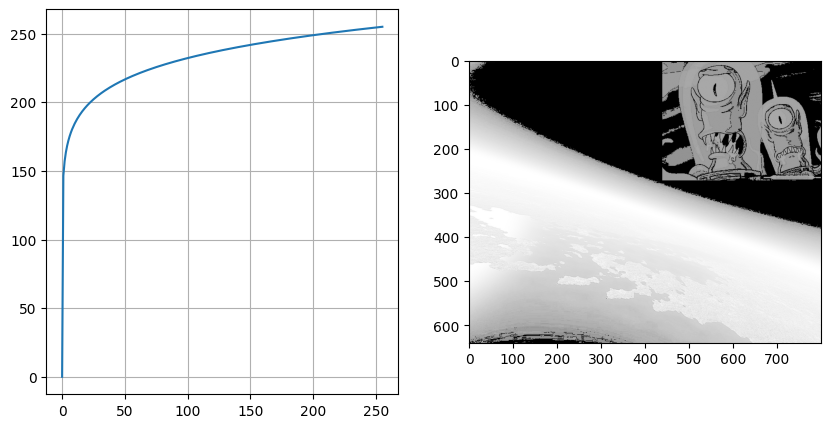

In [ ]:
img = cv2.imread("imagenes/earth.bmp", cv2.IMREAD_GRAYSCALE)

# Aplicar transformacion exponencial
lut_pot = helpers.LUTPotencia(0.1)

fig, ax = plt.subplots(1, 2)
fig.set_figwidth(10)
fig.set_figheight(5)

ax[0].grid()
ax[0].plot(lut_pot)
ax[1].imshow(cv2.LUT(img, lut_pot), cmap='gray');

### Aplicar mascara y realzar ROI

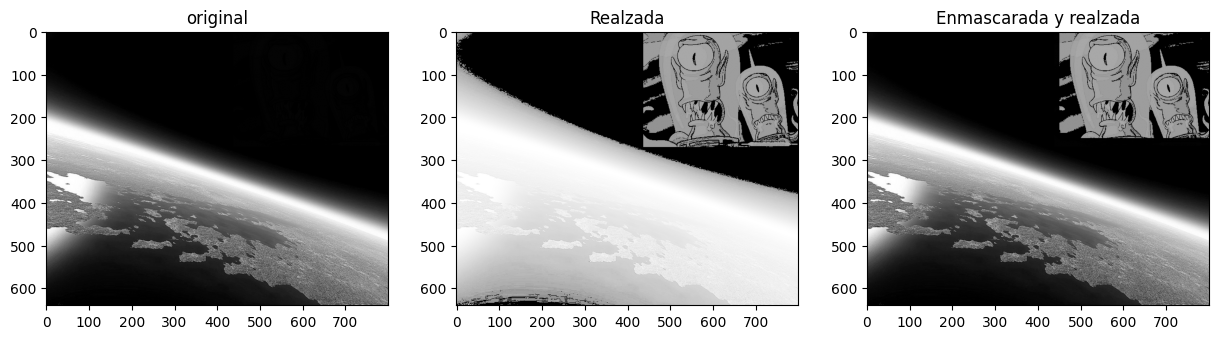

In [12]:
mascara = img.copy()
mascara[:,:] = 0
mascara[0:250, 450:mascara.shape[1]] = 1

img_realzada = cv2.LUT(img, lut_pot)
img_mask_realzada = img.copy()
img_mask_realzada[mascara > 0] = img_realzada[mascara > 0]

fig, ax = plt.subplots(1,3)
fig.set_figwidth(15)
  
ax[0].set_title("original")
ax[0].imshow(img, cmap='gray')
ax[1].set_title("Realzada")
ax[1].imshow(img_realzada, cmap='gray')
ax[2].set_title("Enmascarada y realzada")
ax[2].imshow(img_mask_realzada, cmap='gray');

## 2 - Clasificar placas madres

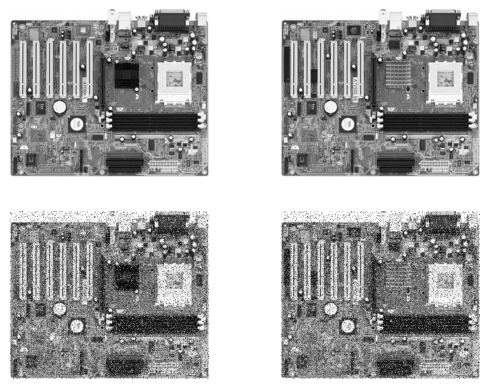

In [ ]:
mb_x = cv2.imread("imagenes/a7v600-X.gif", cv2.IMREAD_GRAYSCALE)
mb_se = cv2.imread("imagenes/a7v600-SE.gif", cv2.IMREAD_GRAYSCALE)
mb_x_n = cv2.imread("imagenes/a7v600-X(RImpulsivo).gif", cv2.IMREAD_GRAYSCALE)
mb_se_n = cv2.imread("imagenes/a7v600-SE(RImpulsivo).gif", cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(2,2)
ax[0,0].axis('off')
ax[0,0].imshow(mb_x, cmap='gray')
ax[0,1].axis('off')
ax[0,1].imshow(mb_se, cmap='gray')
ax[1,0].axis('off')
ax[1,0].imshow(mb_x_n, cmap='gray')
ax[1,1].axis('off')
ax[1,1].imshow(mb_se_n, cmap='gray')

### Realzar y medir niveles de gris promedio en ROI

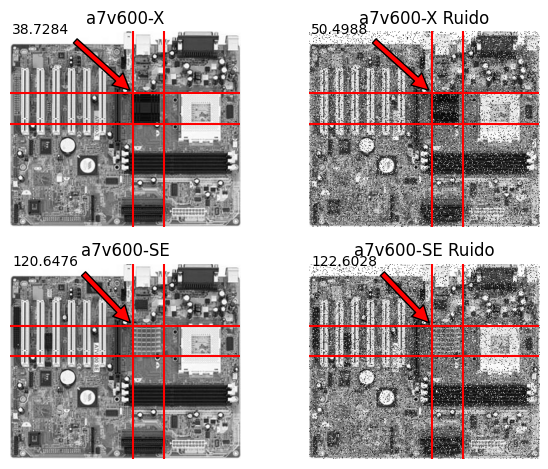

In [14]:
fig, ax = plt.subplots(2,2)
# X
ax[0,0].set_title('a7v600-X')
ax[0,0].axis('off')
ax[0,0].imshow(mb_x, cmap='gray')
ax[0,0].axhline(100, c='r')
ax[0,0].axhline(150, c='r')
ax[0,0].axvline(200, c='r')
ax[0,0].axvline(250, c='r')
ax[0,0].annotate(mb_x[100:150, 200:250].mean(), xy=(200,100), xytext=(3,1.5),
               arrowprops=dict(facecolor='red', shrink=0.05)
)
ax[0,1].set_title('a7v600-X Ruido')
ax[0,1].axis('off')
ax[0,1].imshow(mb_x_n, cmap='gray')
ax[0,1].axhline(100, c='r')
ax[0,1].axhline(150, c='r')
ax[0,1].axvline(200, c='r')
ax[0,1].axvline(250, c='r')
ax[0,1].annotate(mb_x_n[100:150, 200:250].mean(), xy=(200,100), xytext=(3,1.5),
               arrowprops=dict(facecolor='red', shrink=0.05)
)

# SE
ax[1,0].set_title('a7v600-SE')
ax[1,0].axis('off')
ax[1,0].imshow(mb_se, cmap='gray')
ax[1,0].axhline(100, c='r')
ax[1,0].axhline(150, c='r')
ax[1,0].axvline(200, c='r')
ax[1,0].axvline(250, c='r')
ax[1,0].annotate(mb_se[100:150, 200:250].mean(), xy=(200,100), xytext=(3,1.5),
               arrowprops=dict(facecolor='red', shrink=0.05)
)
ax[1,1].set_title('a7v600-SE Ruido')
ax[1,1].axis('off')
ax[1,1].imshow(mb_se_n, cmap='gray')
ax[1,1].axhline(100, c='r')
ax[1,1].axhline(150, c='r')
ax[1,1].axvline(200, c='r')
ax[1,1].axvline(250, c='r')
ax[1,1].annotate(mb_se_n[100:150, 200:250].mean(), xy=(200,100), xytext=(3,1.5),
               arrowprops=dict(facecolor='red', shrink=0.05)
)

fig.tight_layout();

### Definir un umbral en ROI para clasificar modelos de placa madre

In [15]:
def clasificarA7V600(img: cv2.typing.MatLike) -> str:
    return 'X' if img[100:150, 200:250].mean() < 70 else 'SE'

print(clasificarA7V600(mb_x))
print(clasificarA7V600(mb_x_n))
print(clasificarA7V600(mb_se))
print(clasificarA7V600(mb_se_n))

X
X
SE
SE


## 3 - Identificar blisters incompletos

tudo bem


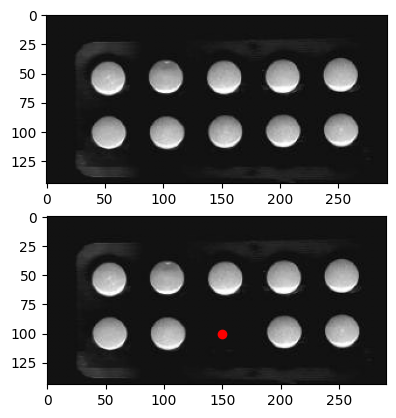

In [ ]:
def analizar_blister(img: cv2.typing.MatLike) -> np.ndarray[tuple[float]]:
    # posiciones de las pildoras
    pildoras = [
        [50,50],
        [100,50],
        [150,50],
        [200,50],
        [250,50],
        [50,100],
        [100,100],
        [150,100],
        [200,100],
        [250,100]
    ]

    # determinar presencia segun un umbral
    faltantes = []
    for pos in pildoras:
        if img[pos[1], pos[0]] < 100:
            faltantes.append(pos)

    if len(faltantes) > 0:
        return np.array(faltantes)

    print("tudo bem")
    return  np.array([])

blister_full = cv2.imread("imagenes/blister_completo.jpg", cv2.IMREAD_GRAYSCALE)
blister_fullnt = cv2.imread("imagenes/blister_incompleto.jpg", cv2.IMREAD_GRAYSCALE)

fig, ax = plt.subplots(2)

ax[0].imshow(blister_full, cmap='gray')
faltantes = analizar_blister(blister_full)
if len(faltantes) > 0:
    ax[0].plot(faltantes[:,0], faltantes[:,1], 'o', c='r')

ax[1].imshow(blister_fullnt, cmap='gray');
faltantes = analizar_blister(blister_fullnt)
if len(faltantes) > 0:
    ax[1].plot(faltantes[:,0], faltantes[:,1], 'o', c='r')